# MEV — Máxima Extração de Valor na Rede Polygon
**Pesquisa FAPEMIG** | Coordenador: Prof. José Augusto Miranda Nacif | Bolsista: Aline Cristina Santos Silva

---

Este notebook documenta a **coleta e análise de dados on-chain** da rede Polygon (Layer-2),
com foco na medição do *Reordering Slippage* em swaps da Uniswap V3.

### Objetivo
Coletar eventos de Swap reais da blockchain para, posteriormente, calcular o slippage de reordenação
e comparar com a linha de base da Ethereum Mainnet — validando a hipótese **H** da proposta:
> *Contratos inteligentes em redes L2 apresentam um reordering slippage significativamente menor do que na rede principal Ethereum.*

### Perguntas de Pesquisa endereçadas
- **RQ1:** Qual a magnitude da diferença no Reordering Slippage médio entre Ethereum Mainnet e Polygon?
- **RQ2:** Qual a proporção entre Slippage Adversário (MEV) e Slippage de Colisão (benigno)?
- **RQ3:** Ativos voláteis (memecoins) apresentam maior slippage adversário também em L2?

---

## 1. Instalação de Dependências

Bibliotecas necessárias:
- **`web3`** — interface com nós da blockchain via RPC
- **`pandas`** — manipulação e análise dos dados coletados
- **`python-dotenv`** — carrega variáveis de ambiente do arquivo `.env` (protege a API key)
- **`matplotlib` / `seaborn`** — visualizações

In [1]:
# Execute uma vez para instalar as dependências
%pip install web3 pandas python-dotenv matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Configuração — Carregando Credenciais

A API key da Alchemy fica armazenada no arquivo **`.env`** (nunca versionado no GitHub).
O arquivo `.env.example` no repositório documenta quais variáveis são necessárias sem expor os valores reais.



## 3. Conexão com a Rede Polygon via Alchemy

A conexão é feita via **RPC (Remote Procedure Call)** — um protocolo que permite consultar
o estado da blockchain sem precisar baixar todos os dados localmente.

A **Alchemy** atua como provedor de nó, fornecendo acesso à Polygon Mainnet de forma confiável e escalável.

**Por que Polygon?**
Por ser uma rede L2, espera-se que o *reordering slippage* seja menor do que na Ethereum Mainnet —
essa é exatamente a hipótese que esta pesquisa busca validar empiricamente.

In [2]:
import os
import requests
from dotenv import load_dotenv
from web3 import Web3
from web3.middleware import ExtraDataToPOAMiddleware

load_dotenv(override=True)
API_KEY = os.getenv("ALCHEMY_API_KEY")
RPC_URL = f"https://polygon-mainnet.g.alchemy.com/v2/{API_KEY}"

# Sessão customizada sem verificação SSL
session = requests.Session()
session.verify = False

from web3.middleware import ExtraDataToPOAMiddleware
from requests.adapters import HTTPAdapter

w3 = Web3(Web3.HTTPProvider(RPC_URL, session=session))
w3.middleware_onion.inject(ExtraDataToPOAMiddleware, layer=0)

try:
    bloco = w3.eth.block_number
    print(f" Conectado! Bloco: {bloco:,}")
except Exception as e:
    print(f" Erro: {e}")

/home/aline/slippage-analysis/venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'polygon-mainnet.g.alchemy.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


 Conectado! Bloco: 86,730,090


## 4. Definição do Contrato — Pool Uniswap V3 (USDC/WETH)

Na Uniswap V3, cada par de tokens possui um **contrato de pool dedicado**.
Toda vez que um swap ocorre, o contrato emite um **evento `Swap`** — um log público e imutável
gravado na blockchain, contendo:

| Campo | Descrição | Relevância para a pesquisa |
|---|---|---|
| `sqrtPriceX96` | Preço de execução real codificado | Base para calcular o slippage |
| `amount0 / amount1` | Volume negociado de cada token | Tamanho do swap (impacto no preço) |
| `sender / recipient` | Endereços envolvidos | Identificar padrões de ataque sandwich |
| `tick` | Posição na curva de preço | Faixa de liquidez utilizada |
| `blockNumber` | Bloco em que ocorreu | Agrupar transações por bloco para cálculo do reordering slippage |

Começamos com o pool **USDC/WETH 0.05%** por ser um dos mais líquidos na Polygon —
ideal para calibrar a metodologia antes de analisar ativos voláteis (RQ3).

In [3]:
# Endereço do pool USDC/WETH 0.05% na Polygon (Uniswap V3)
POOL_ADDRESS = Web3.to_checksum_address("0x45dda9cb7c25131df268515131f647d726f50608")

# ABI mínimo — apenas o evento Swap (não precisamos do ABI completo)
POOL_ABI = [
    {
        "anonymous": False,
        "inputs": [
            {"indexed": True,  "name": "sender",       "type": "address"},
            {"indexed": True,  "name": "recipient",    "type": "address"},
            {"indexed": False, "name": "amount0",      "type": "int256"},
            {"indexed": False, "name": "amount1",      "type": "int256"},
            {"indexed": False, "name": "sqrtPriceX96", "type": "uint160"},
            {"indexed": False, "name": "liquidity",    "type": "uint128"},
            {"indexed": False, "name": "tick",         "type": "int24"}
        ],
        "name": "Swap",
        "type": "event"
    }
]

contrato = w3.eth.contract(address=POOL_ADDRESS, abi=POOL_ABI)
print(f" Contrato carregado: {POOL_ADDRESS}")
print(f" Pool: USDC/WETH 0.05% — Uniswap V3 na Polygon")

 Contrato carregado: 0x45dDa9cb7c25131DF268515131f647d726f50608
 Pool: USDC/WETH 0.05% — Uniswap V3 na Polygon


## 5. Coleta de Eventos de Swap

Consultamos os **logs da blockchain** em um intervalo de blocos recentes,
filtrando apenas os eventos `Swap` do pool selecionado.

Na Polygon, cada bloco leva ~2 segundos — 500 blocos ≈ últimos 16 minutos de transações.

> **Nota metodológica:** Para a análise completa do Reordering Slippage, será necessário
> coletar um volume maior de blocos. Esta célula serve como validação da pipeline de coleta.

In [4]:
import time

JANELA_BLOCOS = 10

bloco_fim    = w3.eth.block_number
bloco_inicio = bloco_fim - 200

print(f" Coletando eventos Swap em lotes de {JANELA_BLOCOS} blocos...")
print(f"   Bloco inicial : {bloco_inicio:,}")
print(f"   Bloco final   : {bloco_fim:,}")
print()

todos_eventos = []

for inicio in range(bloco_inicio, bloco_fim, JANELA_BLOCOS):
    fim = min(inicio + JANELA_BLOCOS - 1, bloco_fim)
    try:
        eventos = contrato.events.Swap.get_logs(
            from_block=inicio,
            to_block=fim
        )
        todos_eventos.extend(eventos)
        print(f"    Blocos {inicio:,} → {fim:,} | {len(eventos)} swaps")
    except Exception as e:
        print(f"    Blocos {inicio:,} → {fim:,} | Erro: {e}")
    time.sleep(0.3)

print(f"\n Total coletado: {len(todos_eventos)} swaps")
eventos = todos_eventos

/home/aline/slippage-analysis/venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'polygon-mainnet.g.alchemy.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


 Coletando eventos Swap em lotes de 10 blocos...
   Bloco inicial : 86,729,891
   Bloco final   : 86,730,091



/home/aline/slippage-analysis/venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'polygon-mainnet.g.alchemy.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


    Blocos 86,729,891 → 86,729,900 | 2 swaps


/home/aline/slippage-analysis/venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'polygon-mainnet.g.alchemy.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

    Blocos 86,730,061 → 86,730,070 | 2 swaps


/home/aline/slippage-analysis/venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'polygon-mainnet.g.alchemy.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


    Blocos 86,730,071 → 86,730,080 | 1 swaps


/home/aline/slippage-analysis/venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'polygon-mainnet.g.alchemy.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


    Blocos 86,730,081 → 86,730,090 | 1 swaps

 Total coletado: 13 swaps


## 6. Estruturação dos Dados em DataFrame

Convertemos os eventos brutos da blockchain em um **DataFrame pandas** estruturado.
Cada linha representa um swap individual, com todos os campos necessários para
o cálculo do Reordering Slippage na próxima etapa.

In [5]:
import csv
import json
from pathlib import Path

def evento_para_dict(evento):
    """Converte um evento Web3 para um dicionário plano com todos os campos."""
    d = {}

    # ── Campos do topo ────────────────────────────────────────────────────────
    d["event"]            = evento.get("event")
    d["address"]          = evento.get("address")
    d["blockNumber"]      = evento.get("blockNumber")
    d["transactionIndex"] = evento.get("transactionIndex")
    d["logIndex"]         = evento.get("logIndex")

    # HexBytes → string legível
    tx_hash    = evento.get("transactionHash")
    block_hash = evento.get("blockHash")
    d["transactionHash"] = tx_hash.hex()    if tx_hash    else None
    d["blockHash"]       = block_hash.hex() if block_hash else None

    # ── Args (parâmetros do Swap) ─────────────────────────────────────────────
    args = evento.get("args", {})
    for chave, valor in args.items():
        if hasattr(valor, "hex"):                  # HexBytes
            valor = valor.hex()
        elif isinstance(valor, (dict, list)):       # estrutura aninhada
            valor = json.dumps(valor, default=str)
        d[f"args_{chave}"] = valor

    return d


# ── Gera as linhas ────────────────────────────────────────────────────────────
linhas = [evento_para_dict(e) for e in todos_eventos]

if not linhas:
    print("Nenhum evento para salvar.")
else:
    todas_colunas = list(dict.fromkeys(k for linha in linhas for k in linha))

    caminho_csv = Path("swaps.csv")
    with caminho_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=todas_colunas, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(linhas)

    print(f"{len(linhas)} swaps salvos em '{caminho_csv.resolve()}'")
    print(f"   Colunas ({len(todas_colunas)}): {todas_colunas}")

13 swaps salvos em '/home/aline/slippage-analysis/swaps.csv'
   Colunas (14): ['event', 'address', 'blockNumber', 'transactionIndex', 'logIndex', 'transactionHash', 'blockHash', 'args_sender', 'args_recipient', 'args_amount0', 'args_amount1', 'args_sqrtPriceX96', 'args_liquidity', 'args_tick']


## 7. Conversão do Preço (sqrtPriceX96 → Preço Legível)

O campo `sqrtPriceX96` armazena o preço em formato interno da Uniswap V3:
a **raiz quadrada do preço**, multiplicada por 2⁹⁶ (para evitar decimais na EVM).

Para obter o preço real em USDC por WETH, aplicamos:

$$price = \left(\frac{sqrtPriceX96}{2^{96}}\right)^2 \times \frac{10^{decimais\_token0}}{10^{decimais\_token1}}$$

Para USDC (6 decimais) / WETH (18 decimais):

$$price_{USDC/WETH} = \left(\frac{sqrtPriceX96}{2^{96}}\right)^2 \times 10^{12}$$

 Este preço de execução real é a base para calcular o **Reordering Slippage** — a diferença entre o preço que o usuário obteve e o preço que obteria em uma ordem aleatória de transações.

In [10]:
import pandas as pd

df = pd.read_csv("swaps.csv")

df = df.rename(columns={
    "blockNumber":       "bloco",
    "transactionIndex":  "tx_index",
    "args_sqrtPriceX96": "sqrtPriceX96",
    "args_amount0":      "amount0",
    "args_amount1":      "amount1",
    "args_sender":       "sender",
    "args_recipient":    "recipient",
})

df["sqrtPriceX96"] = pd.to_numeric(df["sqrtPriceX96"])
df["amount0"]      = pd.to_numeric(df["amount0"])
df["amount1"]      = pd.to_numeric(df["amount1"])

# ── Cálculo do preço ──────────────────────────────────────────────────────────
Q96 = 2 ** 96

def sqrt_price_to_price(sqrt_price_x96):
    """Converte sqrtPriceX96 → preço USDC por WETH.
    token0 = USDC (6 decimais), token1 = WETH (18 decimais)
    """
    ratio = (sqrt_price_x96 / Q96) ** 2    # dá token1/token0 = WETH/USDC (bruto)
    preco_weth_usdc = ratio / 1e12         # corrige decimais → ainda WETH por USDC
    return 1 / preco_weth_usdc             # inverte → USDC por WETH

df["preco_execucao"] = df["sqrtPriceX96"].apply(sqrt_price_to_price)

print("Preços calculados!")
print(f"  Preço médio : ${df['preco_execucao'].mean():,.2f} USDC/WETH")
print(f"  Mínimo      : ${df['preco_execucao'].min():,.2f}")
print(f"  Máximo      : ${df['preco_execucao'].max():,.2f}")
print()
df[["bloco", "tx_index", "preco_execucao", "amount0", "amount1"]].head(10)

Preços calculados!
  Preço médio : $2,337.50 USDC/WETH
  Mínimo      : $2,336.32
  Máximo      : $2,339.11



,bloco,tx_index,preco_execucao,amount0,amount1
0,86729896,167,2336.806458,46756214,-20000000000000000
1,86729900,162,2337.135939,46762806,-20000000000000000
2,86729926,32,2339.108510,280077279,-119727373603976964
3,86729933,37,2338.695668,-58603419,25068486615935924
4,86729933,137,2338.366375,-46747235,20000000000000000
5,86729934,161,2337.936977,-60963387,26086367697203618
6,86729936,135,2337.607516,-46732066,20000000000000000
7,86729949,160,2337.647638,5693721,-2434465633824281
8,86729986,44,2337.588435,-8397221,3594010000000000
9,86730068,62,2337.141349,-63417398,27145578832000097


## 8. Análise Exploratória Inicial

Antes de calcular o Reordering Slippage, exploramos visualmente os dados coletados
para verificar a qualidade da amostra e identificar padrões iniciais.

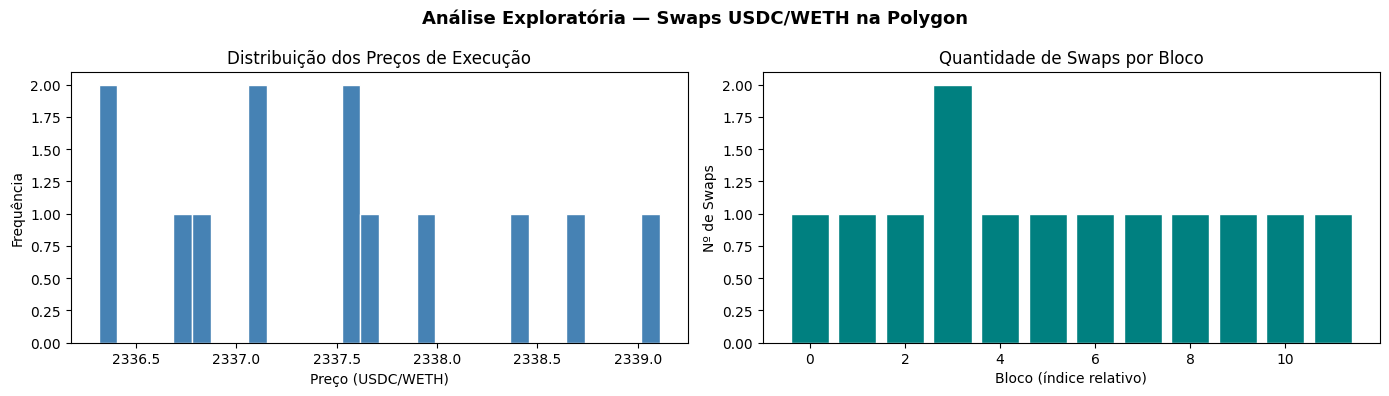

 Gráfico salvo em exploratorio_polygon.png


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Análise Exploratória — Swaps USDC/WETH na Polygon", fontsize=13, fontweight="bold")

# Gráfico 1: Distribuição de preços de execução
axes[0].hist(df["preco_execucao"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição dos Preços de Execução")
axes[0].set_xlabel("Preço (USDC/WETH)")
axes[0].set_ylabel("Frequência")

# Gráfico 2: Swaps por bloco
swaps_por_bloco = df.groupby("bloco").size()
axes[1].bar(range(len(swaps_por_bloco)), swaps_por_bloco.values, color="teal", edgecolor="white")
axes[1].set_title("Quantidade de Swaps por Bloco")
axes[1].set_xlabel("Bloco (índice relativo)")
axes[1].set_ylabel("Nº de Swaps")

plt.tight_layout()
plt.savefig("exploratorio_polygon.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Gráfico salvo em exploratorio_polygon.png")